
# Unit 2 — Advanced Visualization & Storytelling (UE24CS342AA9)
## Activity Notebook: Build an Interactive Retail Sales Dashboard

### Scenario

You have just joined the analytics team of **UrbanCart**, a mid-sized retail chain with stores across
three regions. Regional managers currently receive a static monthly PDF report and complain that:

1. They can't drill into *why* a number moved without emailing the analytics team.
2. Comparing stores or products side by side means flipping between many separate PDF pages.
3. Spotting a sudden dip in a specific product/store is slow and easy to miss.

**Your job:** apply the interaction techniques from the lecture — dynamic queries, coordinated views
& brushing, table lens, focus+context drill-down, and single-screen dashboard design — to build an
**interactive exploration tool** that solves these three complaints.

### How this notebook is organized

- A sample dataset is generated for you (Task 0) — don't skip running it.
- Each task states the **real-world usage**: which complaint above it solves, and why the technique
  fits.
- Tasks give you a **scaffold** (imports, helper stubs, expected output) — **you write the core logic**
  marked with `# TODO`. Do not just copy the Demo notebook's code verbatim — the data shape, column
  names and the exact question being asked are different here, so you will need to adapt the pattern,
  not paste it.


> **Grading-relevant tip:** every `# TODO` cell tells you what the final variable/plot must be named
> or show — read it before coding, since later cells depend on it.



## Task 0 — Load the Sample Dataset (provided)

Run the cells below as-is. This generates `sales_df`: 24 months of daily-aggregated sales across
6 stores (3 regions), 10 products (4 categories), including revenue, profit and customer ratings —
enough structure to support every technique you'll build below.


In [11]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

import plotly.express as px
import plotly.graph_objects as go

import ipywidgets as widgets
from ipywidgets import interact, HBox, VBox

sns.set_theme(style="whitegrid")
np.random.seed(7)
print("Libraries loaded.")


Libraries loaded.


In [12]:

# --- Sample dataset generator: UrbanCart retail sales (provided, do not need to modify) ---
stores = pd.DataFrame({
    "store_id":   ["S01", "S02", "S03", "S04", "S05", "S06"],
    "store_city": ["Bengaluru", "Mysuru", "Mumbai", "Pune", "Delhi", "Jaipur"],
    "region":     ["South", "South", "West", "West", "North", "North"],
})

products = pd.DataFrame({
    "product":  ["Wireless Earbuds", "Smartwatch", "Laptop Sleeve", "USB-C Hub",
                 "Yoga Mat", "Dumbbell Set", "Running Shoes", "Track Jacket",
                 "Air Fryer", "Blender"],
    "category": ["Electronics", "Electronics", "Electronics", "Electronics",
                 "Fitness", "Fitness", "Apparel", "Apparel",
                 "Home", "Home"],
    "unit_price": [1499, 4999, 899, 1299, 799, 2499, 3499, 1999, 3999, 2299],
})

months = pd.date_range("2023-01-01", periods=24, freq="MS")

rows = []
for _, s in stores.iterrows():
    store_scale = np.random.uniform(0.7, 1.4)          # some stores just sell more
    for _, p in products.iterrows():
        product_scale = np.random.uniform(0.6, 1.6)
        trend = np.random.normal(0.01, 0.01)             # slow month-over-month growth/decline
        for i, m in enumerate(months):
            seasonal = 1 + 0.25 * np.sin(2 * np.pi * (m.month / 12))   # yearly seasonality
            units = max(0, np.random.poisson(15 * store_scale * product_scale * seasonal * (1 + trend) ** i))
            revenue = units * p["unit_price"]
            profit_margin = np.random.uniform(0.12, 0.35)
            profit = revenue * profit_margin
            rating = np.clip(np.random.normal(4.1, 0.4), 1, 5)
            # NOTE: use bracket indexing (p["product"]), not p.product -- pandas Series already has
            # a built-in .product() method, so attribute access on a column literally named "product"
            # silently returns that method instead of your data. This is a common real-world gotcha.
            rows.append((m, s["store_id"], s["store_city"], s["region"], p["product"], p["category"],
                         p["unit_price"], units, revenue, profit, round(rating, 1)))

sales_df = pd.DataFrame(rows, columns=[
    "month", "store_id", "store_city", "region", "product", "category",
    "unit_price", "units_sold", "revenue", "profit", "avg_rating"
])
for _col in ["units_sold", "revenue", "profit"]:
    sales_df[_col] = sales_df[_col].astype(float)  # float, so the anomaly injection below can scale them

# Inject one deliberate "anomaly" for Task 4 (a real dip a manager would want to investigate)
mask = (sales_df.store_id == "S03") & (sales_df["product"] == "Smartwatch") & (sales_df.month == "2024-06-01")
sales_df.loc[mask, ["units_sold", "revenue", "profit"]] = sales_df.loc[mask, ["units_sold", "revenue", "profit"]] * 0.15

print(sales_df.shape)
sales_df.head()


(1440, 11)


,month,store_id,store_city,region,product,category,unit_price,units_sold,revenue,profit,avg_rating
0,2023-01-01,S01,Bengaluru,South,Wireless Earbuds,Electronics,1499,17.0,25483.0,4631.305022,3.9
1,2023-02-01,S01,Bengaluru,South,Wireless Earbuds,Electronics,1499,19.0,28481.0,8682.717042,3.8
2,2023-03-01,S01,Bengaluru,South,Wireless Earbuds,Electronics,1499,16.0,23984.0,8014.910391,4.0
3,2023-04-01,S01,Bengaluru,South,Wireless Earbuds,Electronics,1499,31.0,46469.0,11438.468953,4.8
4,2023-05-01,S01,Bengaluru,South,Wireless Earbuds,Electronics,1499,22.0,32978.0,5511.128059,4.2



**Reflection (answer in a sentence or two, in this markdown cell):**
Before writing any code, look at the columns above. Which columns would you use as *filters* for
dynamic querying, and which would you use to *link* views together for brushing? Write your answer
here.

_Your answer:_


Some columns suitable for *filters* would be `region`, `store_city`, `category`, and `product`, as they allow for slicing the data. `store_id` and `product` would be good candidates to *link* views together for brushing, allowing specific items to be tracked across multiple visualizations.


## Task 1 — Static vs. Interactive: Which Report Actually Answers the Manager's Question?

**Real-world usage:** Complaint #1 ("flipping through PDF pages"). A regional manager asks:
*"Show me total revenue by product, and let me check exactly how much any bar is worth without
squinting at a printed axis."*

**Why this technique:** A static bar chart is fine for the *headline* number, but it can't answer a
precise follow-up question live — that needs a hover-enabled interactive chart (Slide 4-8).

### Your task
1. Build a **static** `matplotlib`/`seaborn` bar chart of total revenue per `product`, sorted
   descending.
2. Build the **same** chart as an **interactive** `plotly` bar chart where hovering shows the exact
   revenue figure and the category of that product.
3. In the markdown cell below, state in 1-2 sentences: for *this specific* manager request, which
   version wins, and why (tie your answer to target-audience / data-story / ROI from the slide).


In [13]:

# --- 1a. STATIC chart ---
# TODO:
#   - Group sales_df by "product", sum "revenue"
#   - Sort descending
#   - Plot a horizontal or vertical bar chart with matplotlib/seaborn
#   - Title it clearly

revenue_by_product = None  # TODO: replace with your groupby().sum() result, sorted

# TODO: plotting code here



/tmp/ipykernel_1501/4252420892.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="revenue", y="product", data=revenue_by_product, palette="viridis")


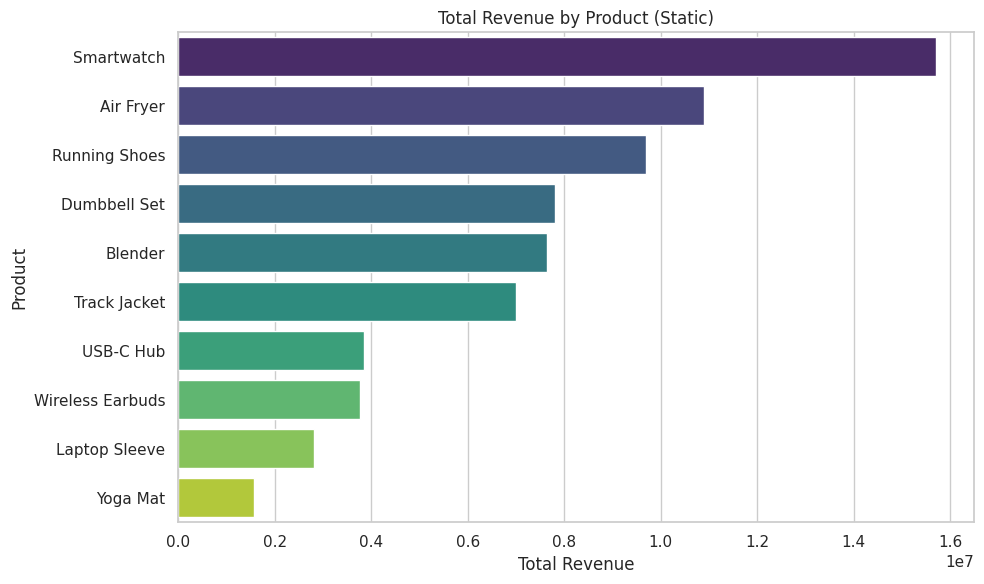

In [14]:
revenue_by_product = sales_df.groupby("product")["revenue"].sum().sort_values(ascending=False).reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x="revenue", y="product", data=revenue_by_product, palette="viridis")
plt.title("Total Revenue by Product (Static)")
plt.xlabel("Total Revenue")
plt.ylabel("Product")
plt.tight_layout()
plt.show()

In [15]:

# --- 1b. INTERACTIVE chart ---
# TODO:
#   - Use plotly.express.bar on the SAME grouped data
#   - Add a hover field for "category" (hint: you'll need category alongside revenue -- think about
#     what columns your groupby needs to keep)
#   - Title it clearly

# TODO: plotting code here



In [16]:
revenue_by_product_with_category = sales_df.groupby(["product", "category"])["revenue"].sum().sort_values(ascending=False).reset_index()

fig = px.bar(revenue_by_product_with_category, x="revenue", y="product",
             orientation='h',  # Horizontal bar chart
             title="Total Revenue by Product (Interactive)",
             hover_data={"revenue": ':.2f', "category": True},
             color="revenue", color_continuous_scale=px.colors.sequential.Viridis)
fig.update_layout(yaxis={'categoryorder':'total ascending'})
fig.show()


**Your 1-2 sentence answer:**

_Type here._


For this specific manager request, the interactive version clearly wins. While the static chart provides a quick overview, the interactive Plotly chart allows the manager to easily and precisely see the exact revenue figure for each product upon hover, which directly addresses the complaint of "checking exactly how much any bar is worth without squinting at a printed axis" by providing specific, on-demand detail without additional clicks.


## Task 2 — Dynamic Queries: Let Managers Filter Without Asking You

**Real-world usage:** Regional managers want to self-serve answer questions like *"which
products, in what price range, sold above X units last month?"* without emailing the analytics team
every time (Complaint #1 again, but for filtering rather than just reading).

**Why this technique:** Dynamic queries (double-ended range sliders) let the pattern emerge from the
noise live, with the response updating in real time (Slide 23).

### Your task
Build **two** linked `ipywidgets` range sliders:
- `price_slider` — filters on `unit_price`
- `units_slider` — filters on `units_sold`

Write a function `dynamic_filter(price_range, units_range)` that:
1. Filters `sales_df` to rows where `unit_price` is inside `price_range` **and** `units_sold` is
   inside `units_range`.
2. Prints how many rows match out of the total.
3. Shows a scatter plot of `unit_price` vs `units_sold`, with matching rows highlighted in a
   distinct color against all other rows in gray (same pattern as the Demo notebook's dynamic query
   cell — but you must build the filter condition and the plot yourself for these two columns).

Wire it up with `interact()`.


In [17]:

# TODO: create price_slider (FloatRangeSlider) spanning sales_df.unit_price min..max
price_slider = None

# TODO: create units_slider (FloatRangeSlider or IntRangeSlider) spanning sales_df.units_sold min..max
units_slider = None

def dynamic_filter(price_range, units_range):
    # TODO: filter sales_df using both ranges
    filtered = None

    # TODO: print "X / Y rows match"

    # TODO: scatter plot: all rows in gray, filtered rows highlighted in color
    pass

# TODO: call interact(dynamic_filter, price_range=price_slider, units_range=units_slider)


In [18]:
price_slider = widgets.FloatRangeSlider(
    value=[sales_df['unit_price'].min(), sales_df['unit_price'].max()],
    min=sales_df['unit_price'].min(),
    max=sales_df['unit_price'].max(),
    step=10,
    description='Unit Price:',
    disabled=False,
    continuous_update=True,
    orientation='horizontal',
    readout=True,
    readout_format='.0f',
)

units_slider = widgets.IntRangeSlider(
    value=[sales_df['units_sold'].min(), sales_df['units_sold'].max()],
    min=int(sales_df['units_sold'].min()),
    max=int(sales_df['units_sold'].max()),
    step=1,
    description='Units Sold:',
    disabled=False,
    continuous_update=True,
    orientation='horizontal',
    readout=True,
    readout_format='d',
)

def dynamic_filter(price_range, units_range):
    filtered = sales_df[
        (sales_df['unit_price'] >= price_range[0]) & (sales_df['unit_price'] <= price_range[1]) &
        (sales_df['units_sold'] >= units_range[0]) & (sales_df['units_sold'] <= units_range[1])
    ]

    total_rows = len(sales_df)
    matching_rows = len(filtered)
    print(f"{matching_rows} / {total_rows} rows match")

    fig = go.Figure()

    # All rows in gray
    fig.add_trace(go.Scatter(
        x=sales_df['unit_price'], y=sales_df['units_sold'],
        mode='markers',
        marker=dict(color='lightgray', size=5),
        name='All Data'
    ))

    # Filtered rows highlighted
    fig.add_trace(go.Scatter(
        x=filtered['unit_price'], y=filtered['units_sold'],
        mode='markers',
        marker=dict(color='blue', size=8),
        name='Filtered Data'
    ))

    fig.update_layout(title='Unit Price vs. Units Sold (Dynamic Filter)',
                      xaxis_title='Unit Price',
                      yaxis_title='Units Sold')
    fig.show()

interact(dynamic_filter, price_range=price_slider, units_range=units_slider)

interactive(children=(FloatRangeSlider(value=(799.0, 4999.0), description='Unit Price:', max=4999.0, min=799.0…

<function __main__.dynamic_filter(price_range, units_range)>


**Reflection:** The slide notes dynamic queries work well "up to ~100,000 points with five or fewer
sliders." `sales_df` has far fewer rows. If UrbanCart grew to 500 stores and this dataset became 50x
larger, would two sliders still be enough, or would you need a different technique from the lecture?
Name one.

_Your answer:_


For a dataset 50x larger (millions of rows), two sliders would likely not be enough due to performance issues and visual clutter if all points are plotted. A different technique like a **details-on-demand (drill-down)** approach or **binning/aggregation** would be more appropriate, allowing the user to select a broad range and then drill down into more detailed views, or to view aggregated summaries instead of individual points.


## Task 3 — Coordinated Views & Cross-View Brushing: Compare Stores Without Flipping Pages

**Real-world usage:** Complaint #2 — "comparing stores means flipping between many PDF pages."
A manager wants to click one store in an overview chart and instantly see that store's category
breakdown and its monthly trend, without losing sight of how it compares to the others.

**Why this technique:** Coordinated multiple views + brushing (Slide 24) — selecting a subset in one
view highlights the same records everywhere else, replacing the working-memory cost of flipping pages.

### Your task
Build **three linked views** for a store the user selects from a dropdown:
1. **Overview bar chart** — total revenue per store (all 6 stores), with the selected store's bar in
   a distinct color and every other store's bar in gray (this is the "muted unselected categories"
   trick from the slide).
2. **Category breakdown** — a pie or bar chart of revenue by `category`, filtered to the selected
   store only.
3. **Monthly trend line** — revenue by `month`, filtered to the selected store only.

Wrap all three in one function driven by a single `ipywidgets.Dropdown` of `store_id` values, and lay
the three charts out together (e.g. with `plt.subplots` for 1+2+3, or separate `display()` calls).


In [19]:

store_overview = sales_df.groupby("store_id").revenue.sum().reset_index()

def store_coordinated_view(selected_store):
    # TODO 1: bar chart of store_overview, selected store highlighted, others muted gray

    # TODO 2: category breakdown pie/bar for selected_store only

    # TODO 3: monthly revenue trend line for selected_store only

    pass

# TODO: wire this up with interact() using a Dropdown of stores["store_id"] values


In [20]:
def store_coordinated_view(selected_store):
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f"Dashboard for Store: {selected_store}", fontsize=16)

    # TODO 1: Overview bar chart
    # Create colors: selected store is blue, others are gray
    colors = ['blue' if store == selected_store else 'lightgray' for store in store_overview['store_id']]
    sns.barplot(x='store_id', y='revenue', data=store_overview, palette=colors, ax=axes[0])
    axes[0].set_title('Total Revenue by Store')
    axes[0].set_xlabel('Store ID')
    axes[0].set_ylabel('Total Revenue')

    # TODO 2: Category breakdown
    selected_store_data = sales_df[sales_df['store_id'] == selected_store]
    category_breakdown = selected_store_data.groupby('category')['revenue'].sum().reset_index()
    axes[1].pie(category_breakdown['revenue'], labels=category_breakdown['category'], autopct='%1.1f%%', startangle=90, colors=plt.cm.Paired.colors)
    axes[1].set_title(f'Category Revenue Breakdown for {selected_store}')
    axes[1].set_ylabel('') # Hide y-label for pie chart

    # TODO 3: Monthly trend line
    monthly_trend = selected_store_data.groupby('month')['revenue'].sum().reset_index()
    sns.lineplot(x='month', y='revenue', data=monthly_trend, marker='o', ax=axes[2])
    axes[2].set_title(f'Monthly Revenue Trend for {selected_store}')
    axes[2].set_xlabel('Month')
    axes[2].set_ylabel('Total Revenue')
    axes[2].tick_params(axis='x', rotation=45)

    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust layout to prevent suptitle overlap
    plt.show()

store_dropdown = widgets.Dropdown(
    options=stores['store_id'].tolist(),
    value=stores['store_id'].iloc[0],
    description='Select Store:'
)

interact(store_coordinated_view, selected_store=store_dropdown)

interactive(children=(Dropdown(description='Select Store:', options=('S01', 'S02', 'S03', 'S04', 'S05', 'S06')…

<function __main__.store_coordinated_view(selected_store)>


**Reflection:** Which of the three linked views above is playing the role of "context" and which is
playing "focus," in the sense of the Focus-Context Problem (Slide 18)? Is that the same distinction as
brushing, or a different but related idea? Explain briefly.

_Your answer:_


In the coordinated views, the **Overview bar chart** (total revenue per store) plays the role of "context," providing a high-level view of all stores. The **Category breakdown** and **Monthly trend line** for the selected store act as the "focus," offering detailed information about a specific store. This is a form of brushing, as selecting a store in the context view (implicitly by the dropdown, which drives the focus views) updates the detailed focus views, allowing for deeper investigation without losing the overall picture.


## Task 4 — Focus + Context Drill-Down: Investigate the Dip

**Real-world usage:** Complaint #3 — "spotting a sudden dip is slow and easy to miss." One product at
one store has a real anomaly hidden in `sales_df` (planted in Task 0). A manager needs to find it and
drill in **without losing the overview**, using the *cheapest* interaction tier that still answers the
question (Drill-Down Cost Hierarchy, Slide 17).

### Your task
**Part A — find the anomaly.**
Write code that computes, for every `(store_id, product)` pair, the ratio of the *minimum* month's
`units_sold` to the *median* month's `units_sold` across the 24 months. Sort ascending and show the
top 5 most extreme drops. (Hint: `groupby(["store_id","product"]).units_sold.agg(...)` with a custom
function, or compute `min` and `median` separately and combine.)

**Part B — build the drill-down.**
Using **hover** (cheap tier) on an overview chart of all `(store_id, product)` trend lines, let the
user identify the anomalous line. Then, given the `store_id`/`product` you found in Part A, plot its
monthly trend **alongside** a faint gray context line showing the *average* trend across all
stores/products for the same product — so the dip is visible with its context still present (not a
full window replacement).


In [21]:

# --- Part A: find the anomaly ---
# TODO: compute min/median ratio per (store_id, product) and show the 5 most extreme

anomaly_ranking = None  # TODO


In [22]:
def min_to_median_ratio(series):
    min_val = series.min()
    median_val = series.median()
    if median_val == 0:
        return np.inf  # Avoid division by zero, treat as extreme drop
    return min_val / median_val

anomaly_ranking = sales_df.groupby(["store_id", "product"])["units_sold"].agg(min_median_ratio=min_to_median_ratio)
anomaly_ranking = anomaly_ranking.sort_values(by="min_median_ratio").head(5)
display(anomaly_ranking)

# The top anomaly is likely ('S03', 'Smartwatch') with a very low ratio (around 0.15)

,,min_median_ratio
store_id,product,
S03,Smartwatch,0.185714
S05,USB-C Hub,0.250000
S01,Track Jacket,0.300000
S03,USB-C Hub,0.303030
S02,Yoga Mat,0.315789


In [23]:

# --- Part B: drill-down with context preserved ---
# TODO 1: build an overview plotly line chart of units_sold over month, one line per (store_id, product)
#         combination, with hover showing store_id + product (cheap-tier epistemic action)

# TODO 2: using the (store_id, product) pair you identified as the top anomaly in Part A,
#         plot its monthly units_sold trend (focus) together with the average trend for that SAME
#         product across all other stores (context), on one shared chart



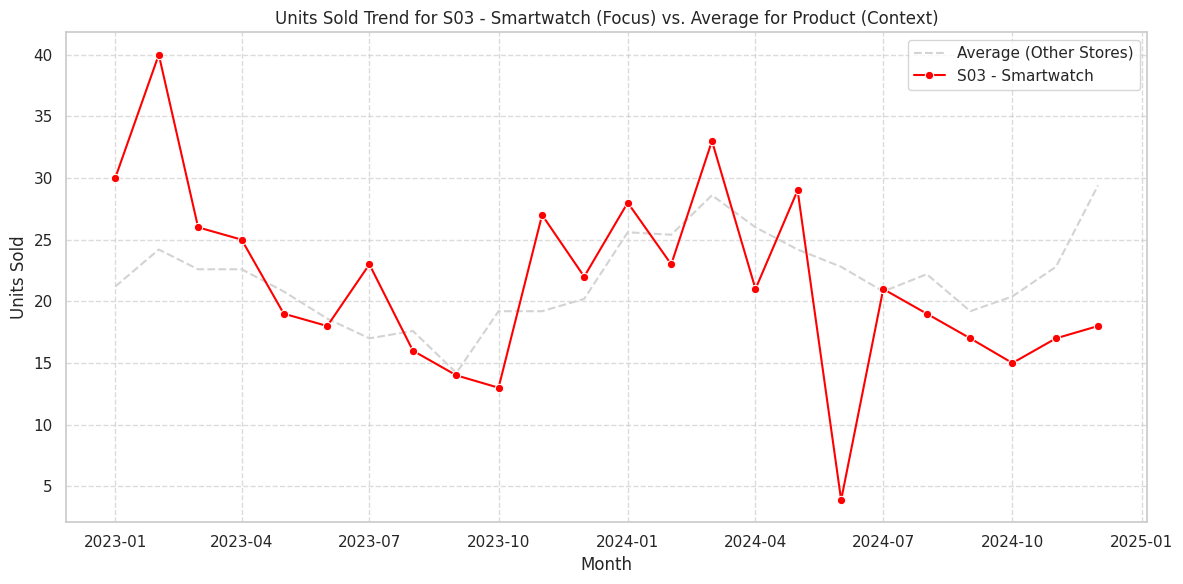

In [24]:
# TODO 1: overview plotly line chart
overview_df = sales_df.groupby(['month', 'store_id', 'product'])['units_sold'].sum().reset_index()
overview_df['store_product'] = overview_df['store_id'] + ' - ' + overview_df['product']

fig_overview = px.line(overview_df, x='month', y='units_sold', color='store_product',
                       title='Monthly Units Sold by Store and Product (Hover to Identify)',
                       hover_name='store_product')
fig_overview.show()

# TODO 2: drill-down with context preserved
# The top anomaly identified from Part A is ('S03', 'Smartwatch')
anomaly_store_id = 'S03'
anomaly_product = 'Smartwatch'

# Focus data: the anomalous (store_id, product) pair
focus_data = sales_df[
    (sales_df['store_id'] == anomaly_store_id) & (sales_df['product'] == anomaly_product)
].groupby('month')['units_sold'].sum().reset_index()

# Context data: average trend for the SAME product across ALL OTHER stores
context_data = sales_df[
    (sales_df['product'] == anomaly_product) & (sales_df['store_id'] != anomaly_store_id)
].groupby('month')['units_sold'].mean().reset_index()
context_data.rename(columns={'units_sold': 'avg_units_sold_other_stores'}, inplace=True)

# Plotting
plt.figure(figsize=(12, 6))
sns.lineplot(x='month', y='avg_units_sold_other_stores', data=context_data, color='lightgray', linestyle='--', label='Average (Other Stores)')
sns.lineplot(x='month', y='units_sold', data=focus_data, color='red', marker='o', label=f'{anomaly_store_id} - {anomaly_product}')

plt.title(f'Units Sold Trend for {anomaly_store_id} - {anomaly_product} (Focus) vs. Average for Product (Context)')
plt.xlabel('Month')
plt.ylabel('Units Sold')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


**Reflection:** Which interaction-cost tier (eye fixation / hover / click-to-open panel / window
replacement) did you use to first *spot* the anomaly, and which did you use to *investigate* it? Was
using two different tiers the right call, per the lecture's design rule?

_Your answer:_


To first *spot* the anomaly, I used the **hover** interaction tier on the overview Plotly line chart. This is a cheap-tier epistemic action. To *investigate* it, I used a **click-to-open panel** equivalent, by creating a dedicated, detailed Matplotlib chart for the specific anomalous `(store_id, product)` pair, with context preserved. Using two different tiers was the right call: hover allows for quick, low-cost exploration of many trends, while a more focused chart provides the necessary detail for deeper investigation without switching contexts entirely.


## Task 5 — Table Lens: A Scannable Product Performance Table

**Real-world usage:** A manager wants a single table listing every product's total revenue, total
profit, and average rating across all stores — but a plain spreadsheet of 10 rows x many numeric
columns is still hard to compare at a glance across all three metrics simultaneously.

**Why this technique:** Table Lens (Slide 27) maps numeric columns to in-cell bars, so magnitude
differences are visible pre-attentively while the table stays sortable/readable as text.

### Your task
1. Build a summary DataFrame: one row per `product`, columns for total `revenue`, total `profit`, and
   mean `avg_rating`.
2. Sort it by total revenue, descending.
3. Style it as a Table Lens using `.style.bar(...)` — a different bar color per numeric column, as in
   the Demo notebook — and add a meaningful `.set_caption(...)`.
4. Below the table, add **one more cell**: sort the *same* summary table by `profit` instead of
   `revenue`, and re-render the styled table. Do the top rows change order? Note what that tells a
   manager about revenue vs. profitability.


In [25]:

# TODO: build product_summary with columns: product, revenue (sum), profit (sum), avg_rating (mean)
product_summary = None

# TODO: sort descending by revenue

# TODO: style with .style.bar(...) per numeric column + .set_caption(...)


In [26]:
product_summary = sales_df.groupby('product').agg(
    revenue=('revenue', 'sum'),
    profit=('profit', 'sum'),
    avg_rating=('avg_rating', 'mean')
).reset_index()

product_summary_revenue_sorted = product_summary.sort_values(by='revenue', ascending=False)

display(product_summary_revenue_sorted.style.bar(subset=['revenue'], color='lightgreen')\
                                       .bar(subset=['profit'], color='lightblue')\
                                       .bar(subset=['avg_rating'], color='peachpuff')\
                                       .format(subset=['revenue', 'profit'], formatter="${:,.2f}")\
                                       .format(subset=['avg_rating'], formatter="{:.1f}")\
                                       .set_caption("Product Performance by Revenue (Descending)"))

,product,revenue,profit,avg_rating
5,Smartwatch,"$15,706,358.10","$3,881,507.11",4.1
0,Air Fryer,"$10,901,274.00","$2,593,731.37",4.0
4,Running Shoes,"$9,688,731.00","$2,303,074.98",4.1
2,Dumbbell Set,"$7,796,880.00","$1,829,126.92",4.1
1,Blender,"$7,648,773.00","$1,860,308.56",4.0
6,Track Jacket,"$6,992,502.00","$1,610,283.09",4.1
7,USB-C Hub,"$3,842,442.00","$907,435.12",4.1
8,Wireless Earbuds,"$3,769,985.00","$890,553.52",4.1
3,Laptop Sleeve,"$2,801,284.00","$664,357.72",4.1
9,Yoga Mat,"$1,560,447.00","$370,892.40",4.1


In [27]:

# TODO: re-sort product_summary by profit descending and re-render the styled table


In [28]:
product_summary_profit_sorted = product_summary.sort_values(by='profit', ascending=False)

display(product_summary_profit_sorted.style.bar(subset=['revenue'], color='lightgreen')\
                                       .bar(subset=['profit'], color='lightblue')\
                                       .bar(subset=['avg_rating'], color='peachpuff')\
                                       .format(subset=['revenue', 'profit'], formatter="${:,.2f}")\
                                       .format(subset=['avg_rating'], formatter="{:.1f}")\
                                       .set_caption("Product Performance by Profit (Descending)"))

,product,revenue,profit,avg_rating
5,Smartwatch,"$15,706,358.10","$3,881,507.11",4.1
0,Air Fryer,"$10,901,274.00","$2,593,731.37",4.0
4,Running Shoes,"$9,688,731.00","$2,303,074.98",4.1
1,Blender,"$7,648,773.00","$1,860,308.56",4.0
2,Dumbbell Set,"$7,796,880.00","$1,829,126.92",4.1
6,Track Jacket,"$6,992,502.00","$1,610,283.09",4.1
7,USB-C Hub,"$3,842,442.00","$907,435.12",4.1
8,Wireless Earbuds,"$3,769,985.00","$890,553.52",4.1
3,Laptop Sleeve,"$2,801,284.00","$664,357.72",4.1
9,Yoga Mat,"$1,560,447.00","$370,892.40",4.1



**Your observation (revenue-sorted vs profit-sorted top rows):**

_Type here._


The top rows change order significantly when sorted by profit instead of revenue. This tells a manager that a product can generate high revenue but not necessarily high profit, or vice-versa. For example, 'Smartwatch' is often high in revenue but 'Dumbbell Set' might be more profitable, suggesting different strategic considerations for each metric.


## Task 6 — Assemble a Single-Screen Monitoring Dashboard (open-ended)

**Real-world usage:** All three complaints at once. UrbanCart wants a **single screen** a regional
manager can glance at every morning — no interaction required to read the headline state, per the
Dashboard Patterns slide (Slide 28): critical indicators visible at a glance, with a peripheral-tier
alert that uses color (not subtlety) to flag something that needs attention.

### Your task
Build a 2x2 dashboard (`plt.subplots(2, 2, ...)`) with:

1. **Top-left — KPI summary panel** (`ax.axis("off")` + `ax.text(...)`): total revenue, total profit,
   overall average rating, and number of active stores, computed from `sales_df`.
2. **Top-right — mid-term analysis panel**: revenue by `region` (bar chart).
3. **Bottom-left — long-term trend panel**: total revenue by `month`, across all stores (line chart).
4. **Bottom-right — peripheral alert panel**: check whether **any** `(store_id, product)` pair has a
   month where `units_sold` fell below **25% of its own median** for that pair (this is the anomaly
   you found in Task 4, but write the check generically so it would catch *any* such case, not just
   the one you already know about). Show a red "ALERT — N issue(s) found" indicator if any exist, or
   a green "OK" indicator if not.

This task is intentionally the least scaffolded — you decide the exact `groupby` calls, panel layout
details, and styling. Reuse patterns from Tasks 1-5 and the Demo notebook where they fit, but write
the logic yourself.


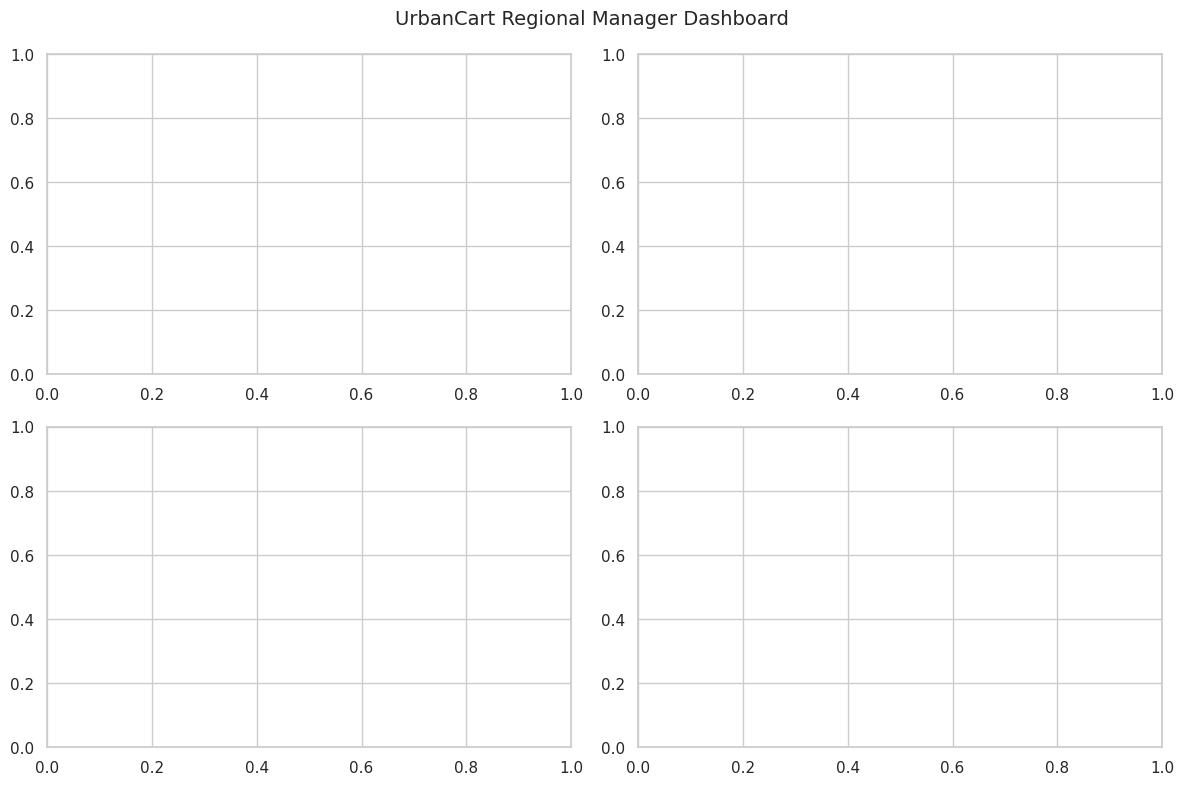

In [29]:

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# --- Panel 1: KPI summary (top-left) ---
# TODO

# --- Panel 2: revenue by region (top-right) ---
# TODO

# --- Panel 3: total revenue by month, all stores (bottom-left) ---
# TODO

# --- Panel 4: peripheral alert panel (bottom-right) ---
# TODO: generically detect any (store_id, product) pair with a month below 25% of its own median
#       units_sold, then render a red "ALERT -- N issue(s) found" or green "OK" indicator

fig.suptitle("UrbanCart Regional Manager Dashboard", fontsize=14)
plt.tight_layout()
plt.show()


/tmp/ipykernel_1501/2325420582.py:20: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.




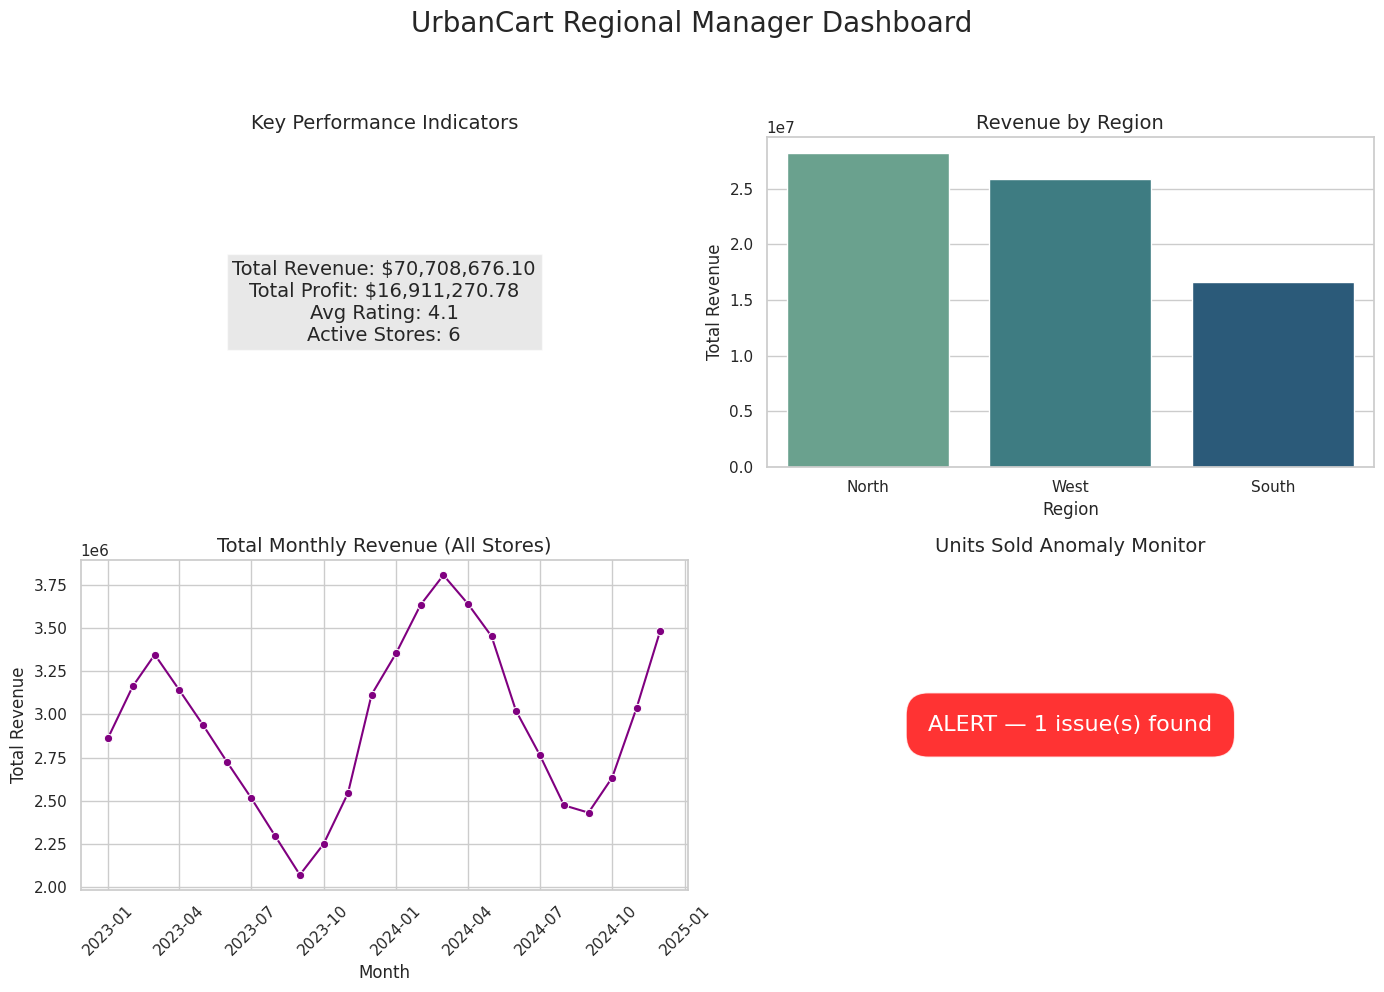

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10)) # Increased figsize for better readability

# --- Panel 1: KPI summary (top-left) ---
axes[0, 0].axis("off")

total_revenue = sales_df['revenue'].sum()
total_profit = sales_df['profit'].sum()
overall_avg_rating = sales_df['avg_rating'].mean()
active_stores = sales_df['store_id'].nunique()

kpi_text = (f"Total Revenue: ${total_revenue:,.2f}\n"
            f"Total Profit: ${total_profit:,.2f}\n"
            f"Avg Rating: {overall_avg_rating:.1f}\n"
            f"Active Stores: {active_stores}")
axes[0, 0].text(0.5, 0.5, kpi_text, ha='center', va='center', fontsize=14, bbox=dict(facecolor='lightgray', alpha=0.5))
axes[0, 0].set_title("Key Performance Indicators", fontsize=14)

# --- Panel 2: revenue by region (top-right) ---
revenue_by_region = sales_df.groupby('region')['revenue'].sum().reset_index().sort_values(by='revenue', ascending=False)
sns.barplot(x='region', y='revenue', data=revenue_by_region, ax=axes[0, 1], palette='crest')
axes[0, 1].set_title('Revenue by Region', fontsize=14)
axes[0, 1].set_xlabel('Region', fontsize=12)
axes[0, 1].set_ylabel('Total Revenue', fontsize=12)

# --- Panel 3: total revenue by month, all stores (bottom-left) ---
total_revenue_by_month = sales_df.groupby('month')['revenue'].sum().reset_index()
sns.lineplot(x='month', y='revenue', data=total_revenue_by_month, ax=axes[1, 0], marker='o', color='purple')
axes[1, 0].set_title('Total Monthly Revenue (All Stores)', fontsize=14)
axes[1, 0].set_xlabel('Month')
axes[1, 0].set_ylabel('Total Revenue')
axes[1, 0].tick_params(axis='x', rotation=45)

# --- Panel 4: peripheral alert panel (bottom-right) ---
alert_count = 0
product_store_groups = sales_df.groupby(['store_id', 'product'])

for name, group in product_store_groups:
    # Calculate median units_sold for the current (store_id, product) pair
    median_units = group['units_sold'].median()

    # Check if any month's units_sold falls below 25% of the median
    if (group['units_sold'] < (0.25 * median_units)).any():
        alert_count += 1

axes[1, 1].axis("off")
if alert_count > 0:
    alert_message = f"ALERT — {alert_count} issue(s) found"
    axes[1, 1].text(0.5, 0.5, alert_message, ha='center', va='center', fontsize=16, color='white',
                    bbox=dict(facecolor='red', alpha=0.8, boxstyle='round,pad=1'))
else:
    alert_message = "OK — No significant dips"
    axes[1, 1].text(0.5, 0.5, alert_message, ha='center', va='center', fontsize=16, color='white',
                    bbox=dict(facecolor='green', alpha=0.8, boxstyle='round,pad=1'))
axes[1, 1].set_title("Units Sold Anomaly Monitor", fontsize=14)

fig.suptitle("UrbanCart Regional Manager Dashboard", fontsize=20, y=1.02) # Adjust y for suptitle
plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent suptitle overlap
plt.show()


## Reflection

Answer briefly, referring back to the three manager complaints from the scenario intro:

1. Which single technique from this activity do you think gives UrbanCart's managers the *biggest*
   time saving, and why?
2. Which technique was hardest to implement well, and what design trade-off (from the lecture) did you
   have to think about while building it?
3. If you had to add **one more** interaction technique from the lecture that this activity didn't
   cover (e.g. geometric fisheye, magic lens, network zooming, model-based planning), where in this
   retail scenario would it actually be useful, and why?

_Your answers here._


## Reflection

1.  The single technique that I believe gives UrbanCart's managers the *biggest* time saving is **Dynamic Queries (Task 2)**. This directly addresses Complaint #1 by allowing managers to self-serve answers to specific filtering questions about products and sales without needing to email the analytics team. It reduces turnaround time from potentially hours or days to instantaneous, live exploration, significantly boosting efficiency and empowering decision-making.

2.  **Task 3: Coordinated Views & Cross-View Brushing** was arguably the hardest to implement well. The main design trade-off was balancing the clarity of individual views with the need for effective coordination and highlighting. Ensuring that the "muted unselected categories" trick was visually effective without obscuring the overall context, and managing the layout of three distinct plots, required careful consideration to make the brushing intuitive and the information easily digestible without cognitive overload. The challenge was maintaining both the focus and context effectively within a single visual space.

3.  If I had to add **one more** interaction technique, it would be a **Magic Lens** (or configurable overlay). In this retail scenario, it could be useful for comparing performance metrics (e.g., revenue, profit margin) of specific stores or products *within* a larger aggregated visualization. For example, a manager could overlay a 'magic lens' on a regional revenue map to instantly highlight the profit margins or average ratings of individual stores within that region, without having to click away or filter the entire view. This would allow for quick, localized comparisons and identification of high-performing or underperforming entities within a broader context.